In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv('movies.csv')

In [9]:
data.head()

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Rotten Tomatoes %,Runtime (mins),Language,Oscars Won,Box Office ($M),Metacritic Score
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman,United States,9.3,91.0,142.0,English,0,58.0,82.0
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino,United States,9.2,98.0,175.0,English,3,246.1,100.0
2,3,The Dark Knight,2008,Action|Crime|Drama,Christopher Nolan,Christian Bale|Heath Ledger,United States|United Kingdom,9.0,94.0,152.0,English,2,1004.9,84.0
3,4,The Godfather: Part II,1974,Crime|Drama,Francis Ford Coppola,Al Pacino|Robert De Niro,United States,9.0,97.0,202.0,English,6,48.5,90.0
4,5,12 Angry Men,1957,Crime|Drama,Sidney Lumet,Henry Fonda|Lee J. Cobb,United States,9.0,100.0,96.0,English,0,1.0,96.0


In [10]:
data.head(100)

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Rotten Tomatoes %,Runtime (mins),Language,Oscars Won,Box Office ($M),Metacritic Score
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman,United States,9.3,91.0,142.0,English,0,58.0,82.0
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino,United States,9.2,98.0,175.0,English,3,246.1,100.0
2,3,The Dark Knight,2008,Action|Crime|Drama,Christopher Nolan,Christian Bale|Heath Ledger,United States|United Kingdom,9.0,94.0,152.0,English,2,1004.9,84.0
3,4,The Godfather: Part II,1974,Crime|Drama,Francis Ford Coppola,Al Pacino|Robert De Niro,United States,9.0,97.0,202.0,English,6,48.5,90.0
4,5,12 Angry Men,1957,Crime|Drama,Sidney Lumet,Henry Fonda|Lee J. Cobb,United States,9.0,100.0,96.0,English,0,1.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Lawrence of Arabia,1962,Adventure|Biography|Drama,David Lean,Peter O'Toole|Omar Sharif,United Kingdom,8.3,98.0,222.0,English,7,70.0,NaN
96,97,The Bridge on the River Kwai,1957,Adventure|Drama|War,David Lean,William Holden|Alec Guinness,United Kingdom|United States,8.1,93.0,161.0,English,7,30.6,NaN
97,98,Double Indemnity,1944,Crime|Drama|Film-Noir,Billy Wilder,Fred MacMurray|Barbara Stanwyck,United States,8.0,98.0,107.0,English,0,5.7,NaN
98,99,Annie Hall,1977,Comedy|Romance,Woody Allen,Woody Allen|Diane Keaton,United States,8.0,97.0,93.0,English,4,38.3,NaN


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               100 non-null    int64  
 1   Title              100 non-null    object 
 2   Year               100 non-null    int64  
 3   Genre(s)           100 non-null    object 
 4   Director           100 non-null    object 
 5   Main Actor(s)      100 non-null    object 
 6   Country            100 non-null    object 
 7   IMDb Rating        99 non-null     float64
 8   Rotten Tomatoes %  97 non-null     float64
 9   Runtime (mins)     99 non-null     float64
 10  Language           100 non-null    object 
 11  Oscars Won         100 non-null    int64  
 12  Box Office ($M)    83 non-null     float64
 13  Metacritic Score   50 non-null     float64
dtypes: float64(5), int64(3), object(6)
memory usage: 11.1+ KB


In [13]:
data.isnull().sum()

,0
Rank,0
Title,0
Year,0
Genre(s),0
Director,0
Main Actor(s),0
Country,0
IMDb Rating,1
Rotten Tomatoes %,3
Runtime (mins),1


In [14]:
data.columns

Index(['Rank', 'Title', 'Year', 'Genre(s)', 'Director', 'Main Actor(s)',
       'Country', 'IMDb Rating', 'Rotten Tomatoes %', 'Runtime (mins)',
       'Language', 'Oscars Won', 'Box Office ($M)', 'Metacritic Score'],
      dtype='object')

In [19]:
data = data.dropna(subset=['IMDb Rating'])

In [20]:
data = data.drop_duplicates()

In [21]:
data['IMDb Rating'] = pd.to_numeric(data['IMDb Rating'], errors='coerce')

In [27]:
mean_IMDbRating = data['IMDb Rating'].mean()
median_IMDbRating = data['IMDb Rating'].median()
mode_IMDbRating = data['IMDb Rating'].mode()[0]

print("Mean IMDb Rating:", round(mean_IMDbRating, 2))
print("Media IMDb Rating:", mode_IMDbRating)

Mean IMDb Rating: 8.39
Media IMDb Rating: 8.1


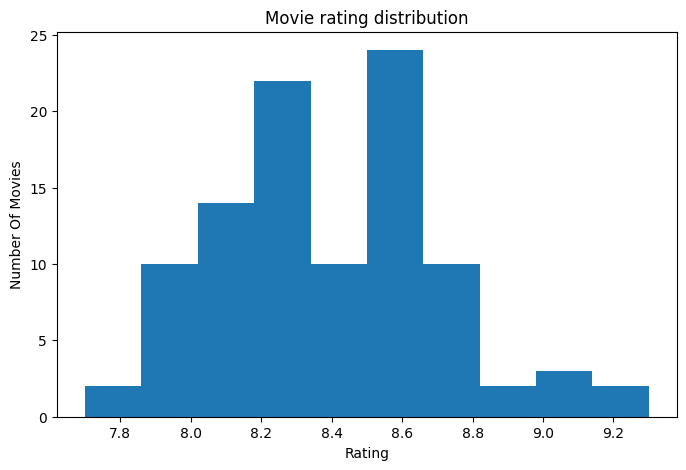

In [28]:
plt.figure(figsize=(8,5))
plt.hist(data['IMDb Rating'], bins=10)
plt.title("Movie rating distribution")
plt.xlabel("Rating")
plt.ylabel("Number Of Movies")
plt.show()

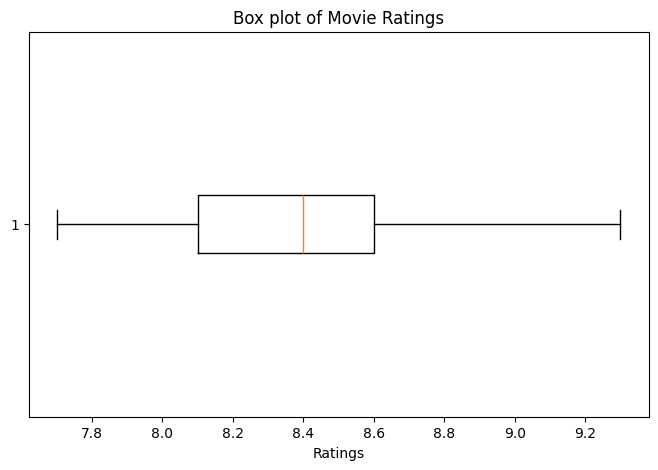

In [29]:
plt.figure(figsize=(8,5))
plt.boxplot(data['IMDb Rating'], vert=False)
plt.title("Box plot of Movie Ratings")
plt.xlabel("Ratings")
plt.show()

In [35]:
top_movies = data.sort_values(by='IMDb Rating', ascending = False).head(10)
top_movies[['Title', 'IMDb Rating']]

,Title,IMDb Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0
5,The Lord of the Rings: The Return of the King,8.9
6,Schindler's List,8.9
7,The Lord of the Rings: The Fellowship of the Ring,8.8
8,Inception,8.8
12,Forrest Gump,8.8


In [37]:
genre_avg = data.groupby('Genre(s)')['IMDb Rating'].mean().sort_values(ascending=False)
genre_avg.head(10)


,IMDb Rating
Genre(s),
Biography|Drama|History,8.900000
Action|Sci-Fi|Thriller,8.800000
Drama|Romance,8.800000
Adventure|Drama|Fantasy,8.800000
Action|Crime|Drama,8.750000
Crime|Drama,8.733333
Biography|Crime|Drama,8.700000
Action|Adventure|Sci-Fi,8.700000
Western,8.650000


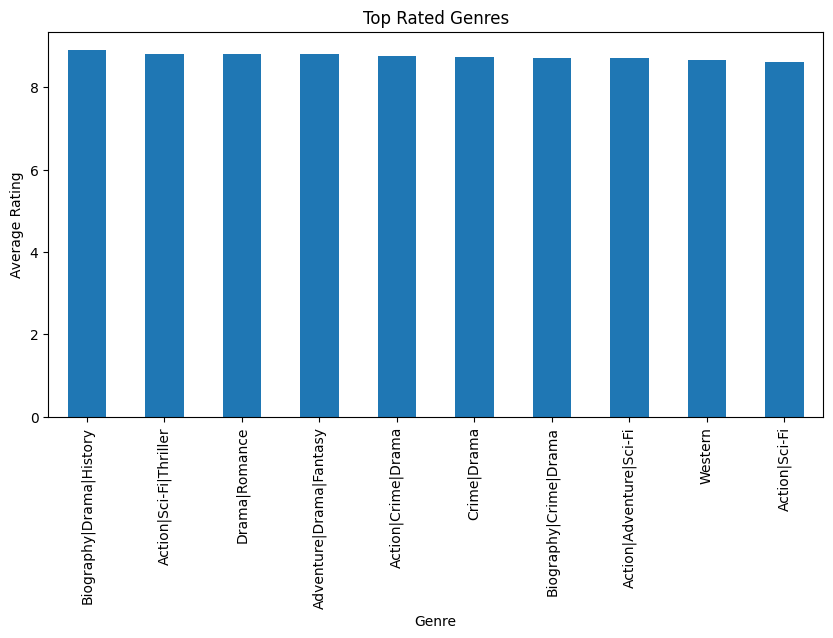

In [39]:
plt.figure(figsize=(10,5))
genre_avg.head(10).plot(kind='bar')
plt.title("Top Rated Genres")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()


In [40]:
data.to_csv("cleaned_movies.csv", index=False)
